In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split


def load_data(file_path):
    df = pd.read_csv(file_path) 
    df = df.dropna(subset=['text'])
    return df

df = load_data('NLP_project.csv')

#Keisha: I added some preprocessing steps to clean the labels and convert them to binary format.
# This should help the model learn more effectively from the data.
df["label"] = df["label"].astype(str).str.lower().str.strip()
df["label"] = df["label"].map({
    "supportive": 1,
    "unsupportive": 0,
})

print(df.head())
print("="*30)

# Sunshine: added the printing for is_pe label
print(df["is_pe"].value_counts(dropna=False))
print("="*30)


# Sunshine: obtain a separate dataset for pe label
df_pe = df.dropna(subset=["is_pe"])
train_df_pe, test_df_pe = train_test_split(df_pe, test_size=0.2, random_state=42, stratify=df_pe["is_pe"])

#Keisha: I also added a step to drop any rows where the label is still missing after the mapping, 
# just to ensure we have clean data for training.
# Sunshine: filter out non_pe data in sentiment dataset
df_sentiment = df[df['is_pe'] == 1]
df_sentiment = df.dropna(subset=["label"])
train_df_sentiment, test_df_sentiment = train_test_split(df_sentiment, test_size=0.2, random_state=42, stratify=df_sentiment["label"])

# filter is_pe=0 data out for sentimental classification training
print(df["label"].value_counts(dropna=False))

   id                                               text  label  is_pe
0   1  Miss Potwine gave into my keeping your preciou...    1.0      1
1   2  the value of health to a lady is inestimable. ...    1.0      1
2   3  Yet despite the emphasis on religion at Holyok...    1.0      1
3   4  Pupils often remark a decided improvement in t...    1.0      1
4   5  It is a duty to be healthy. The rules of this ...    1.0      1
is_pe
1    91
0    26
Name: count, dtype: int64
label
1.0    50
0.0    41
NaN    26
Name: count, dtype: int64


In [2]:
# Sunshine: added a new function to extract features for pe/non_pe model
def extract_pe_id_features(text):
    text = text.lower()

    # word lists
    pe_keywords = ["gym", "exercise", "physical", "calisthenics", "rowing", "health", "outdoor", "games", "athletic"]
    non_pe_keywords = ["latin", "algebra", "bible", "composition", "recitation", "history"]

    # featurestrain_df
    pe_count = sum(word in text for word in pe_keywords)
    non_pe_count = sum(word in text for word in non_pe_keywords)
    
    return np.array([
        pe_count, 
        non_pe_count, 
        len(text.split())
    ], dtype=float)

In [3]:
# B.manually define features
def extract_manual_features(text):
    text = text.lower()

    # Sunshine: improve negation handling
    text = text.replace("not ", "NOT_")
    text = text.replace("no ", "NO_")

    #Keisha: I expanded the positive and negative word lists to include more words that are relevant to the context of health and fitness, 
    # which should help the model capture a wider range of sentiments in the text.
    # word lists
    pos_words = ["exercise", "gym", "gymnasium", "athletic", "health", "games", "strong", "strength", "fit", "fitness", "active", "endurance","benefit"]
    neg_words = ["weak", "delicate", "strain", "masculine", "fragile", "unhealthy", "sickly", "infirm", "frail", "vulnerable", "suffer", "illness", "improper", "wrong", "bad", "unfit", "unwell", "disease", "injury", "pain", "hurt", "damage", "sick", "ill"]

    # features
    pos_count = sum(word in text for word in pos_words)
    neg_count = sum(word in text for word in neg_words)

    has_modal = int("should" in text or "must" in text)
    has_negation = int("not" in text or "no" in text)

    pronouns = ["she", "her", "woman", "women", "girl"]
    pronoun_count = sum(word in text for word in pronouns)

    length = len(text.split())

    return np.array([
        pos_count,
        neg_count,
        #has_modal,
        has_negation,
        #pronoun_count,
        length
    ], dtype=float)

In [22]:
class LogisticRegression:
            
    def __init__(self):
        self.weight = None
        self.bias = 0 
        self.mean = None
        self.std = None
        self.loss_history = []

    def sigmoid(self, Z):
        return 1 / (1 + np.exp(-Z))

    #Keisha: i added eps to prevent log(0) which can cause numerical instability
    def loss(self, a, y):
       eps = 1e-15 # to prevent log(0)
       a = np.clip(a, eps, 1 - eps)
       
       return (-1 / y.shape[0]) * np.sum(y * np.log(a) + (1 - y) * np.log(1 - a))
    
    def train(self, X, y, alpha = 0.1, numIters=100):
        X = np.array(X)
        self.Y = np.array(y).reshape((-1, 1))
        
        # scaling
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        self.std[self.std == 0] = 1
        self.X_scaled = (X - self.mean) / self.std

        # initial weights
        n_features = self.X_scaled.shape[1]
        self.weight = np.zeros((n_features, 1))
        self.bias = 0
        self.gradientDescent(alpha=alpha, numIters=numIters)

    def gradientDescent(self, alpha, numIters):
        # gradient descent
        loss = 0
        for i in range(numIters):
            # dot product of feature and weight plus bias
            Z = np.dot(self.X_scaled, self.weight) + self.bias
            A = self.sigmoid(Z)
            
            # gradients
            grad = np.dot(self.X_scaled.T, (A - self.Y)) / self.Y.shape[0]
            db = np.sum(A - self.Y) / self.Y.shape[0]

            prevLoss = loss
            loss = self.loss(A, self.Y)
            self.loss_history.append(loss)
            stepSize = abs(prevLoss - loss)

            # update
            self.weight -= alpha * grad
            self.bias -= alpha * db
          
          #Keisha:stepSize is just one number, not an array, so we can directly compare it to the threshold without using .any()  
           # if stepSize.any() < 0.000001:
            #    break
            if stepSize < 0.000001:
                break

            

    def predict(self, X):
        X_test_scaled = (np.array(X) - self.mean) / self.std
        z = np.dot(X_test_scaled, self.weight) + self.bias
        y_pred = self.sigmoid(z)
        return (y_pred >= 0.5).astype(int)

In [23]:
# Sunshine: pre-model
X_train_pe = np.array([extract_pe_id_features(t) for t in train_df_pe['text']])
Y_train_pe = train_df_pe['is_pe'].values

model_pe_filter = LogisticRegression()
model_pe_filter.train(X_train_pe, Y_train_pe, alpha=0.1, numIters=1000)

In [24]:
# label

Y_train = train_df_sentiment['label'].values
Y_test = test_df_sentiment['label'].values

# ===manual===
X_train_manual = [extract_manual_features(t) for t in train_df_sentiment['text']]
X_test_manual = [extract_manual_features(t) for t in test_df_sentiment['text']]

model_manual = LogisticRegression()
model_manual.train(X_train_manual, Y_train, alpha=0.01, numIters=1000)

# ==automatically extract features
from sklearn.feature_extraction.text import TfidfVectorizer

#Keisha: I added ngram_range=(1, 2) to include both unigrams and bigrams,
# and max_features=1000 to limit the number of features to the top 1000 most frequent ones. 
# This should help capture more contextual information while keeping the feature space manageable.
vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2), max_features=1000)

X_train_auto = vectorizer.fit_transform(train_df_sentiment['text']).toarray() 
X_test_auto = vectorizer.transform(test_df_sentiment['text']).toarray()

#Keisha: I increased the number of iterations to 1000 to give the model more time to converge, 
# especially since we added a convergence check based on the change in loss. 
# This should help ensure that the model trains effectively without stopping too early.
model_auto = LogisticRegression()
model_auto.train(X_train_auto, Y_train, alpha=0.01, numIters=1000)


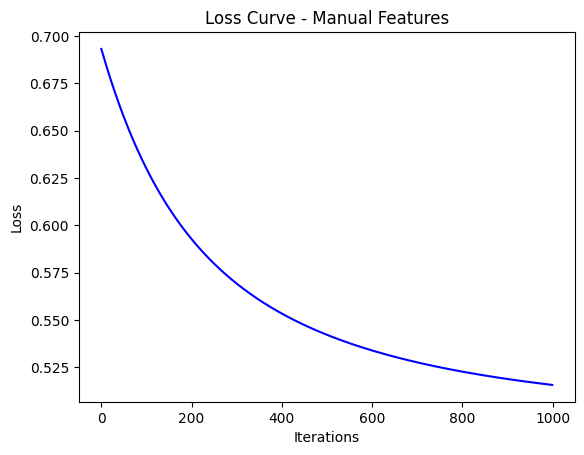

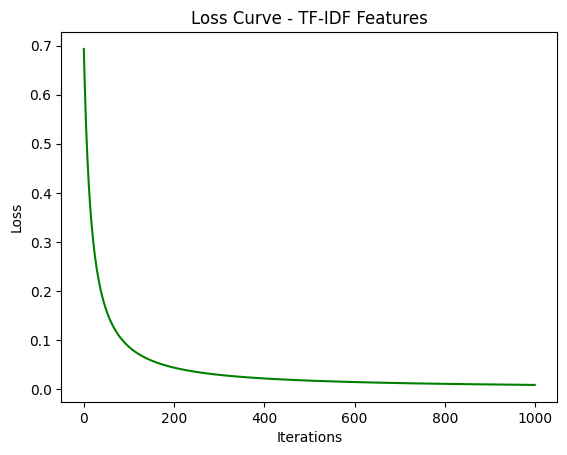

In [26]:
#manual model
plt.plot(model_manual.loss_history, color='blue')
plt.title("Loss Curve - Manual Features")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

#TF-IDF model
plt.plot(model_auto.loss_history, color='green')
plt.title("Loss Curve - TF-IDF Features")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()



In [7]:
def evaluate (model, X, Y, name = 'model'):
    y_pred = model.predict(X)
    accuracy = np.mean(y_pred.flatten() == Y.flatten())
    print(name)
    print('Accuracy: {}'.format(accuracy))

evaluate(model_auto, X_test_auto, Y_test, name = "TF-IDF")
evaluate(model_manual, X_test_manual, Y_test, name = "manual features")

TF-IDF
Accuracy: 0.5789473684210527
manual features
Accuracy: 0.7368421052631579


In [8]:
feature_names = [
    "pos_count",
    "neg_count",
    #"had_modal",
    "negation",
    #"pronouns",
    "length"
]

coefficients = model_manual.weight.flatten()

print("Feature Weights:")
for name, coef in zip(feature_names, coefficients):
    print(f"{name}: {coef:.4f}")

Feature Weights:
pos_count: 0.9826
neg_count: -0.5493
negation: -0.0860
length: 0.2281


In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

def plot_cm(model, X, Y, name):
    # make prediction
    y_pred = model.predict(X)
    
    # Confusion Matrix
    cm = confusion_matrix(Y, y_pred, labels=[0, 1])
    
    print(f"=== {name} Confusion Matrix ===")
    print(cm)
    
    print(f"\n=== {name} Classification Report ===")
    print(classification_report(Y, y_pred))
    
plot_cm(model_manual, X_test_manual, Y_test, name="Manual Model")
plot_cm(model_auto, X_test_auto, Y_test, name = "TF-IDF")

=== Manual Model Confusion Matrix ===
[[7 2]
 [3 7]]

=== Manual Model Classification Report ===
              precision    recall  f1-score   support

         0.0       0.70      0.78      0.74         9
         1.0       0.78      0.70      0.74        10

    accuracy                           0.74        19
   macro avg       0.74      0.74      0.74        19
weighted avg       0.74      0.74      0.74        19

=== TF-IDF Confusion Matrix ===
[[7 2]
 [6 4]]

=== TF-IDF Classification Report ===
              precision    recall  f1-score   support

         0.0       0.54      0.78      0.64         9
         1.0       0.67      0.40      0.50        10

    accuracy                           0.58        19
   macro avg       0.60      0.59      0.57        19
weighted avg       0.61      0.58      0.56        19



In [10]:
X_test_pe = np.array([extract_pe_id_features(t) for t in test_df_pe['text']])
Y_test_pe = test_df_pe['is_pe'].values

plot_cm(model_pe_filter, X_test_pe, Y_test_pe, name="PE Filter Model")

=== PE Filter Model Confusion Matrix ===
[[ 0  5]
 [ 0 19]]

=== PE Filter Model Classification Report ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.79      1.00      0.88        19

    accuracy                           0.79        24
   macro avg       0.40      0.50      0.44        24
weighted avg       0.63      0.79      0.70        24



/home/jupyter-huang64y/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jupyter-huang64y/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/jupyter-huang64y/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [11]:
# weights
manual_weights = model_manual.weight.flatten()
feature_names = ["pos_count", "neg_count", "negation", "length"]

print("--- Manual Features Weights ---")
for name, weight in zip(feature_names, manual_weights):
    print(f"{name:15}: {weight:.4f}")

--- Manual Features Weights ---
pos_count      : 0.9826
neg_count      : -0.5493
negation       : -0.0860
length         : 0.2281


In [12]:
# get tfidf features
tfidf_feature_names = vectorizer.get_feature_names_out()
tfidf_weights = model_auto.weight.flatten()

# rank words by weight
feature_importance = sorted(zip(tfidf_feature_names, tfidf_weights), key=lambda x: x[1], reverse=True)

print("\n=== TF-IDF Top 5 Supportive Words ===")
for word, weight in feature_importance[:5]:
    print(f"{word:20}: {weight:.4f}")

print("\n=== TF-IDF Top 5 Unsupportive Words ===")
for word, weight in feature_importance[-5:]:
    print(f"{word:20}: {weight:.4f}")


=== TF-IDF Top 5 Supportive Words ===
exercise            : 0.1878
constitution females: 0.0935
peculiarly          : 0.0935
peculiarly fitted   : 0.0935
anticipated         : 0.0796

=== TF-IDF Top 5 Unsupportive Words ===
mind sex            : -0.0947
sex education       : -0.0947
sex mind            : -0.0947
boys                : -0.1111
sex                 : -0.1122


In [13]:
pip install sentence-transformers

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [42]:
# trying Sentence-BERT approach
from sentence_transformers import SentenceTransformer

# all-mpnet-base-v2 = a sentence transformer model mapping to 768 dimensional dense vector space
model_embed = SentenceTransformer('all-mpnet-base-v2')

# translate text 
X_train_embed = model_embed.encode(train_df_sentiment["text"].tolist())
X_test_embed = model_embed.encode(test_df_sentiment["text"].tolist())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [44]:
# train bert model
model_bert = LogisticRegression()
model_bert.train(X_train_embed, Y_train, alpha=0.01, numIters=1000)

y_pred = model_bert.predict(X_test_embed)
accuracy = np.mean(y_pred.flatten() == Y_test.flatten())
print('Accuracy: {}'.format(accuracy))

Accuracy: 0.8421052631578947


In [40]:
plot_cm(model_auto, X_test_auto, Y_test, name = "Sentence-BERT")

=== Sentence-BERT Confusion Matrix ===
[[7 2]
 [6 4]]

=== Sentence-BERT Classification Report ===
              precision    recall  f1-score   support

         0.0       0.54      0.78      0.64         9
         1.0       0.67      0.40      0.50        10

    accuracy                           0.58        19
   macro avg       0.60      0.59      0.57        19
weighted avg       0.61      0.58      0.56        19



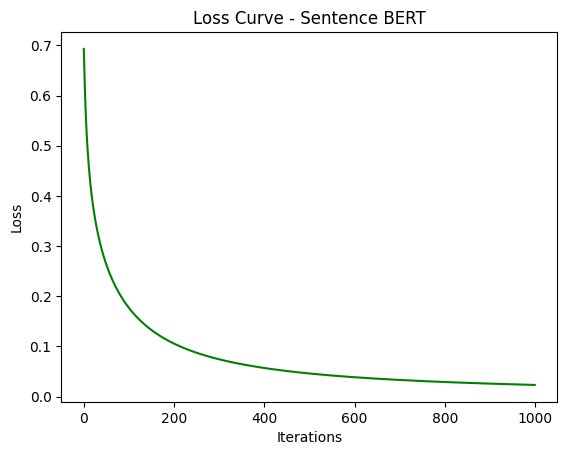

In [41]:
#Sentence BERT model
plt.plot(model_bert.loss_history, color='green')
plt.title("Loss Curve - Sentence BERT")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()
